# 04 - Network Zone Overlay: Energex vs Ergon Analysis

**Project:** DER Integration in Queensland  
**Author:** Johan Lopez  
**Date:** February 2026  

**Purpose:** Overlay Queensland's distribution network operator boundaries (Energex vs Ergon Energy) onto DER deployment data to identify whether high-DER postcodes align with specific network zones and their unique constraints.

**Why this matters:**
- **Energex** = SE Queensland (Brisbane, Gold Coast, Sunshine Coast) → urban, high-density, voltage management challenges
- **Ergon** = Regional Queensland (97% of state land area) → dispersed, rural/remote, distance & reliability challenges

Different network operators = different grid constraints = different battery value propositions.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Add project src directory to path
project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(project_root, 'src'))

# Import custom data loader
from data_loader import load_processed_data

print('✓ Libraries loaded')

✓ Libraries loaded


## 2. Load Enriched DER Data

In [2]:
project_root   = os.path.dirname(os.getcwd())
data_processed = os.path.join(project_root, 'data', 'processed')
outputs_figs   = os.path.join(project_root, 'outputs', 'figures')

# Load the enriched data from notebook 03 using data loader
# This provides helpful error messages if file doesn't exist
df = load_processed_data('qld_der_postcode_enriched.csv', data_processed_path=data_processed)

print(f'✓ Loaded {len(df):,} postcodes with DER + geographic data')
print(f'  Columns: {df.columns.tolist()}')

✓ Loaded qld_der_postcode_enriched.csv: 416 rows
✓ Loaded 416 postcodes with DER + geographic data
  Columns: ['postcode', 'DER_Sites', 'DER_Connections', 'Total_DER_kVA', 'Solar_Connections', 'Solar_Devices', 'Solar_kVA', 'Battery_Connections', 'Battery_Devices', 'Battery_kVA', 'Battery_Storage_kVAh', 'Other_Connections', 'Installed_OtherDER_capacity_kVA', 'Battery_Penetration_pct', 'Devices_per_Connection', 'lat', 'lon', 'Suburb', 'Region']


## 3. Define Network Operator Zones

### 3.1 Energex vs Ergon - Postcode Classification

**Energex service area** (SE Queensland):
- Brisbane metro
- Gold Coast
- Sunshine Coast
- Logan, Ipswich, Moreton Bay, Redlands
- North to Gympie, west to base of Great Dividing Range

**Postcode ranges (approximate):**
- 4000-4179: Brisbane metro & inner suburbs
- 4200-4230: Gold Coast
- 4500-4581: Sunshine Coast, Moreton Bay, Caboolture
- 4300-4390: Ipswich, Logan, western suburbs

**Ergon** = Everything else (regional & remote Queensland)

In [3]:
def classify_network_operator(postcode):
    """
    Classify postcode as Energex or Ergon service area.
    Based on publicly documented service territories.
    """
    try:
        pc_int = int(postcode)
    except:
        return 'Unknown'
    
    # Energex SE Queensland postcodes (approximate ranges)
    energex_ranges = [
        (4000, 4184),  # Brisbane metro & surrounds
        (4200, 4287),  # Gold Coast
        (4300, 4349),  # Ipswich, Logan, western suburbs
        (4500, 4521),  # Moreton Bay, Caboolture
        (4550, 4581),  # Sunshine Coast, Gympie
    ]
    
    for start, end in energex_ranges:
        if start <= pc_int <= end:
            return 'Energex'
    
    # Everything else is Ergon
    return 'Ergon'

# Apply classification
df['Network_Operator'] = df['postcode'].apply(classify_network_operator)

# Summary
operator_counts = df['Network_Operator'].value_counts()
print('Network Operator Classification:')
print('─'*40)
for op, count in operator_counts.items():
    print(f'  {op:<12} {count:>5} postcodes')
print('─'*40)

Network Operator Classification:
────────────────────────────────────────
  Ergon          219 postcodes
  Energex        197 postcodes
────────────────────────────────────────


### 3.2 Validate Classification with Geographic Check

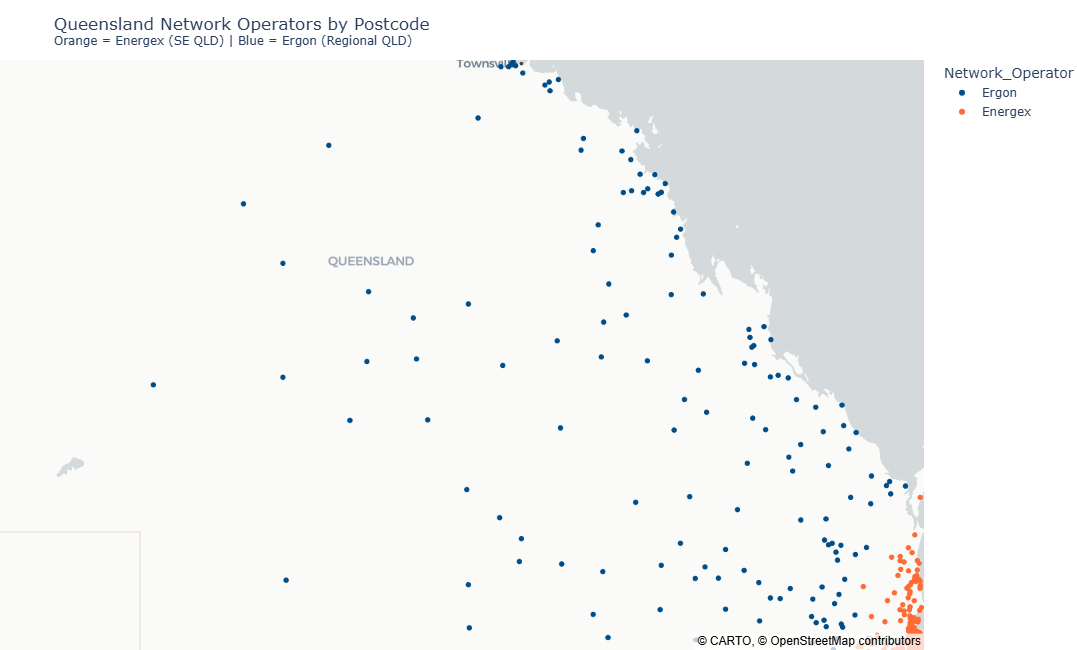


💡 Visual check: Orange cluster should be SE Queensland corridor.


In [4]:
# Quick visual check: plot Energex vs Ergon on map
fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    color='Network_Operator',
    color_discrete_map={'Energex': '#FF6B35', 'Ergon': '#004E89'},
    hover_name='postcode',
    hover_data={'Suburb': True, 'Solar_kVA': ':.0f'},
    zoom=5.5,
    center={'lat': -23.5, 'lon': 146.0},
    map_style='carto-positron',
    title='Queensland Network Operators by Postcode<br>'
          '<sup>Orange = Energex (SE QLD) | Blue = Ergon (Regional QLD)</sup>'
)
fig.update_layout(height=650, margin={'r':0,'t':60,'l':0,'b':0})
fig.show()

print('\n💡 Visual check: Orange cluster should be SE Queensland corridor.')

## 4. DER Deployment Analysis by Network Operator

### 4.1 Aggregate Statistics

In [5]:
network_stats = df.groupby('Network_Operator').agg(
    Postcodes                = ('postcode', 'count'),
    Total_DER_Sites          = ('DER_Sites', 'sum'),
    Total_Solar_MVA          = ('Solar_kVA', lambda x: x.sum()/1000),
    Total_Battery_MVA        = ('Battery_kVA', lambda x: x.sum()/1000),
    Total_Battery_Storage_MVAh = ('Battery_Storage_kVAh', lambda x: x.sum()/1000),
    Avg_Battery_Penetration_pct = ('Battery_Penetration_pct', 'mean'),
).round(1)

# Add percentage of state total
network_stats['Solar_pct_of_State'] = (
    network_stats['Total_Solar_MVA'] / network_stats['Total_Solar_MVA'].sum() * 100
).round(1)

print('='*70)
print('  DER DEPLOYMENT BY NETWORK OPERATOR — Queensland')
print('='*70)
display(network_stats)
print('='*70)

  DER DEPLOYMENT BY NETWORK OPERATOR — Queensland


,Postcodes,Total_DER_Sites,Total_Solar_MVA,Total_Battery_MVA,Total_Battery_Storage_MVAh,Avg_Battery_Penetration_pct,Solar_pct_of_State
Network_Operator,,,,,,,
Energex,197,713759,4776.5,765.3,1428.2,7.9,67.6
Ergon,219,300439,2289.6,228.2,396.3,5.1,32.4


### 4.2 Key Finding Interpretation

In [6]:
energex_solar_pct = network_stats.loc['Energex', 'Solar_pct_of_State']
energex_postcodes = network_stats.loc['Energex', 'Postcodes']
total_postcodes   = network_stats['Postcodes'].sum()

print('🔍 KEY INSIGHT:')
print('─'*60)
print(f'Energex covers {energex_postcodes}/{total_postcodes} postcodes '
      f'({energex_postcodes/total_postcodes*100:.0f}% of postcodes)')
print(f'BUT accounts for {energex_solar_pct:.0f}% of Queensland solar capacity')
print()
print('Translation:')
print('  • SE Queensland = HIGH DENSITY DER deployment')
print('  • Energex network faces URBAN grid constraints:')
print('    - Voltage rise from high solar export')
print('    - Peak demand management')
print('    - Distribution transformer overload risk')
print('  • Batteries in Energex zone = grid stabilization value')
print()
print('  • Regional Queensland (Ergon) = DISPERSED DER')
print('  • Ergon network faces DIFFERENT constraints:')
print('    - Long feeder lines → voltage drop')
print('    - Reliability in remote areas')
print('    - Distance from generation sources')
print('  • Batteries in Ergon zone = backup power + reliability value')
print('─'*60)

🔍 KEY INSIGHT:
────────────────────────────────────────────────────────────
Energex covers 197/416 postcodes (47% of postcodes)
BUT accounts for 68% of Queensland solar capacity

Translation:
  • SE Queensland = HIGH DENSITY DER deployment
  • Energex network faces URBAN grid constraints:
    - Voltage rise from high solar export
    - Peak demand management
    - Distribution transformer overload risk
  • Batteries in Energex zone = grid stabilization value

  • Regional Queensland (Ergon) = DISPERSED DER
  • Ergon network faces DIFFERENT constraints:
    - Long feeder lines → voltage drop
    - Reliability in remote areas
    - Distance from generation sources
  • Batteries in Ergon zone = backup power + reliability value
────────────────────────────────────────────────────────────


## 5. Visualisations with Network Overlay

### 5.1 DER Distribution: Energex vs Ergon

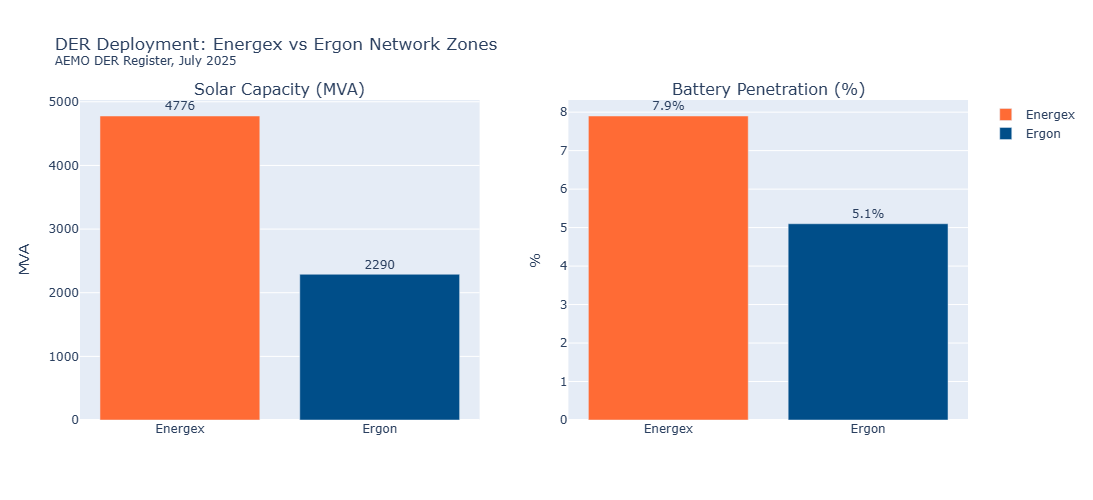

In [7]:
# Bar chart comparison
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Solar Capacity (MVA)', 'Battery Penetration (%)')
)

# Solar capacity
fig.add_trace(
    go.Bar(
        name='Energex',
        x=['Energex'],
        y=[network_stats.loc['Energex', 'Total_Solar_MVA']],
        marker_color='#FF6B35',
        text=[f"{network_stats.loc['Energex', 'Total_Solar_MVA']:.0f}"],
        textposition='outside'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        name='Ergon',
        x=['Ergon'],
        y=[network_stats.loc['Ergon', 'Total_Solar_MVA']],
        marker_color='#004E89',
        text=[f"{network_stats.loc['Ergon', 'Total_Solar_MVA']:.0f}"],
        textposition='outside'
    ),
    row=1, col=1
)

# Battery penetration
fig.add_trace(
    go.Bar(
        name='Energex',
        x=['Energex'],
        y=[network_stats.loc['Energex', 'Avg_Battery_Penetration_pct']],
        marker_color='#FF6B35',
        text=[f"{network_stats.loc['Energex', 'Avg_Battery_Penetration_pct']:.1f}%"],
        textposition='outside',
        showlegend=False
    ),
    row=1, col=2
)
fig.add_trace(
    go.Bar(
        name='Ergon',
        x=['Ergon'],
        y=[network_stats.loc['Ergon', 'Avg_Battery_Penetration_pct']],
        marker_color='#004E89',
        text=[f"{network_stats.loc['Ergon', 'Avg_Battery_Penetration_pct']:.1f}%"],
        textposition='outside',
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title='DER Deployment: Energex vs Ergon Network Zones<br>'
          '<sup>AEMO DER Register, July 2025</sup>',
    height=500,
    showlegend=True
)
fig.update_xaxes(showticklabels=True)
fig.update_yaxes(title_text='MVA', row=1, col=1)
fig.update_yaxes(title_text='%', row=1, col=2)
fig.show()

### 5.2 Enhanced Bubble Map with Network Operator Overlay

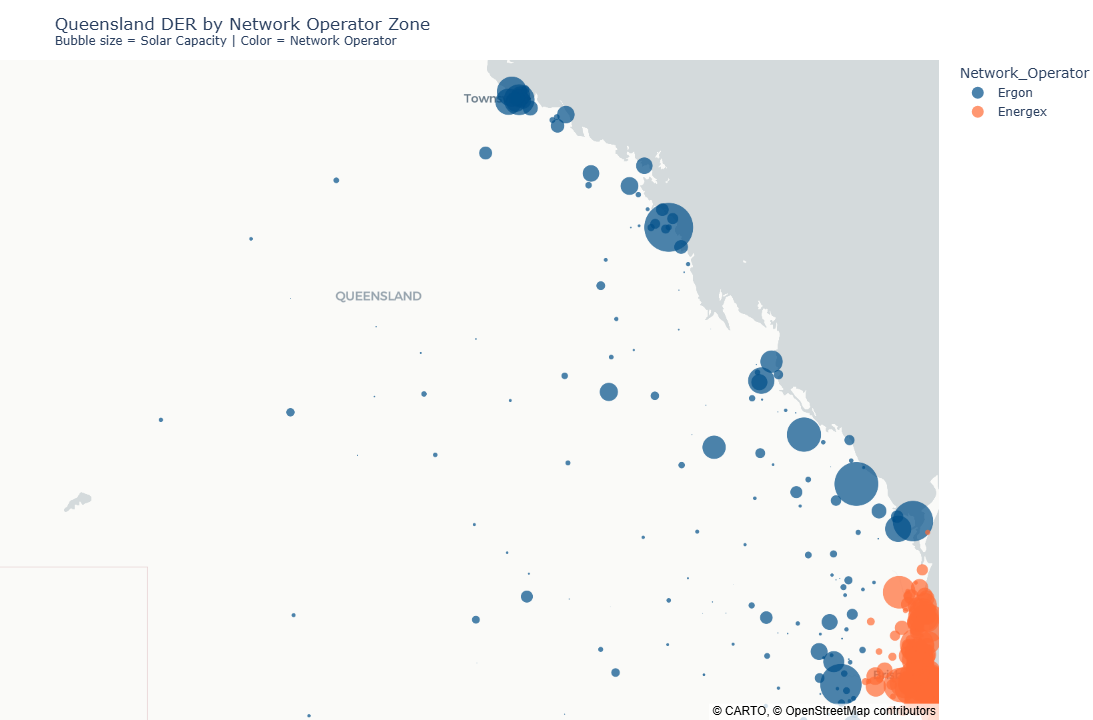

💡 Notice: Larger bubbles concentrated in Energex (orange) zone.
   This visual correlation confirms high DER density in SE QLD.


In [8]:
# Create map with network operator as color
fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    size='Solar_kVA',
    color='Network_Operator',
    color_discrete_map={'Energex': '#FF6B35', 'Ergon': '#004E89'},
    hover_name='postcode',
    hover_data={
        'Suburb'                  : True,
        'Network_Operator'        : True,
        'Solar_kVA'               : ':.0f',
        'Battery_Penetration_pct' : ':.1f',
        'DER_Sites'               : True,
    },
    size_max=35,
    zoom=5.5,
    center={'lat': -23.5, 'lon': 146.0},
    map_style='carto-positron',
    title='Queensland DER by Network Operator Zone<br>'
          '<sup>Bubble size = Solar Capacity | Color = Network Operator</sup>'
)
fig.update_layout(
    height=720,
    margin={'r':0,'t':60,'l':0,'b':0}
)
fig.show()

print('💡 Notice: Larger bubbles concentrated in Energex (orange) zone.')
print('   This visual correlation confirms high DER density in SE QLD.')

### 5.3 Top Postcodes by Network Operator

In [9]:
# Top 10 in each network zone
top_energex = (
    df[df['Network_Operator']=='Energex']
    .nlargest(10, 'Solar_kVA')
    [['postcode','Suburb','Solar_kVA','DER_Sites','Battery_Penetration_pct']]
)

top_ergon = (
    df[df['Network_Operator']=='Ergon']
    .nlargest(10, 'Solar_kVA')
    [['postcode','Suburb','Solar_kVA','DER_Sites','Battery_Penetration_pct']]
)

print('Top 10 Energex Postcodes (SE Queensland):')
print('─'*60)
display(top_energex.reset_index(drop=True))

print('\nTop 10 Ergon Postcodes (Regional Queensland):')
print('─'*60)
display(top_ergon.reset_index(drop=True))

Top 10 Energex Postcodes (SE Queensland):
────────────────────────────────────────────────────────────


,postcode,Suburb,Solar_kVA,DER_Sites,Battery_Penetration_pct
0,4207,ALBERTON,116084,14480,8.2
1,4551,AROONA,110374,17683,7.0
2,4300,AUGUSTINE HEIGHTS,101442,14437,8.6
3,4209,CANOWINDRA,97032,13216,9.3
4,4306,AMBERLEY,87682,12937,9.3
5,4510,BALINGOOL,84649,12729,8.1
6,4211,ADVANCETOWN,84032,13035,8.6
7,4570,AMAMOOR,78496,12100,7.6
8,4305,BASIN POCKET,72458,12131,8.0
9,4500,BRAY PARK,72372,10229,7.5



Top 10 Ergon Postcodes (Regional Queensland):
────────────────────────────────────────────────────────────


,postcode,Suburb,Solar_kVA,DER_Sites,Battery_Penetration_pct
0,4740,ALEXANDRA,173603,17190,7.2
1,4670,ABBOTSFORD,139990,20858,5.6
2,4350,ATHOL,124668,16847,4.1
3,4655,BOORAL,119384,18968,4.7
4,4870,AEROGLEN,107137,12033,5.7
5,4680,BARMUNDU,86127,11728,5.4
6,4814,AITKENVALE,69823,9110,6.9
7,4818,BEACH HOLM,66441,8655,10.3
8,4352,AMIENS,55281,7810,5.0
9,4701,BERSERKER,51814,7696,5.3


## 6. Battery Market Opportunity by Network Zone

### 6.1 Untapped Battery Market Segmented by Network Operator

In [10]:
# Calculate untapped battery market
battery_opportunity = df.groupby('Network_Operator').apply(
    lambda g: pd.Series({
        'Solar_Connections': g['Solar_Connections'].sum(),
        'Battery_Connections': g['Battery_Connections'].sum(),
        'Untapped_Customers': g['Solar_Connections'].sum() - g['Battery_Connections'].sum(),
        'Battery_Penetration_%': (g['Battery_Connections'].sum() / g['Solar_Connections'].sum() * 100).round(1),
        'Market_Potential_%': (100 - (g['Battery_Connections'].sum() / g['Solar_Connections'].sum() * 100)).round(1)
    })
).astype({'Solar_Connections': int, 'Battery_Connections': int, 'Untapped_Customers': int})

print('='*65)
print('  BATTERY MARKET OPPORTUNITY BY NETWORK ZONE')
print('='*65)
display(battery_opportunity)
print('='*65)

energex_untapped = battery_opportunity.loc['Energex', 'Untapped_Customers']
ergon_untapped   = battery_opportunity.loc['Ergon', 'Untapped_Customers']

print(f'\n📊 Market Sizing:')
print(f'  Energex zone: {energex_untapped:,} solar customers without batteries')
print(f'  Ergon zone:   {ergon_untapped:,} solar customers without batteries')
print()
print('  Different value propositions:')
print('  • Energex = grid services, bill savings, voltage management')
print('  • Ergon   = backup power, reliability, energy independence')

  BATTERY MARKET OPPORTUNITY BY NETWORK ZONE


,Solar_Connections,Battery_Connections,Untapped_Customers,Battery_Penetration_%,Market_Potential_%
Network_Operator,,,,,
Energex,797016,64390,732626,8.1,91.9
Ergon,364895,21228,343667,5.8,94.2



📊 Market Sizing:
  Energex zone: 732,626 solar customers without batteries
  Ergon zone:   343,667 solar customers without batteries

  Different value propositions:
  • Energex = grid services, bill savings, voltage management
  • Ergon   = backup power, reliability, energy independence


### 6.2 Strategic Insight: Network-Specific Battery Value

In [11]:
print('='*70)
print('  STRATEGIC IMPLICATIONS FOR BATTERY DEPLOYMENT')
print('='*70)
print()
print('ENERGEX ZONE (SE Queensland):')
print('  Network context:')
print('    • High DER density → voltage rise challenges')
print('    • Distribution transformers approaching capacity limits')
print('    • Peak demand periods (5-8pm) stress network')
print()
print('  Battery value proposition:')
print('    ✓ Voltage management (reduce midday export → control voltage)')
print('    ✓ Peak demand reduction (discharge 5-8pm → reduce grid load)')
print('    ✓ VPP participation (controllable capacity at scale)')
print('    ✓ Network deferral value (delay infrastructure upgrades)')
print()
print('  Installer opportunity:')
print(f'    • {energex_untapped:,} potential customers')
print('    • High density = lower customer acquisition cost')
print('    • Combine: bill savings + grid services + VPP earnings')
print()
print('─'*70)
print()
print('ERGON ZONE (Regional Queensland):')
print('  Network context:')
print('    • Long feeder lines → voltage drop at end-of-line')
print('    • Reliability issues (storms, bushfires, equipment failure)')
print('    • Remote areas with expensive grid connection')
print()
print('  Battery value proposition:')
print('    ✓ Backup power during outages (reliability, peace of mind)')
print('    ✓ Energy independence (reduce reliance on distant grid)')
print('    ✓ Voltage support at end-of-line locations')
print('    ✓ Microgrid potential for community resilience')
print()
print('  Installer opportunity:')
print(f'    • {ergon_untapped:,} potential customers')
print('    • Lower density = higher customer acquisition cost')
print('    • Pitch: reliability + independence (not just bill savings)')
print()
print('='*70)

  STRATEGIC IMPLICATIONS FOR BATTERY DEPLOYMENT

ENERGEX ZONE (SE Queensland):
  Network context:
    • High DER density → voltage rise challenges
    • Distribution transformers approaching capacity limits
    • Peak demand periods (5-8pm) stress network

  Battery value proposition:
    ✓ Voltage management (reduce midday export → control voltage)
    ✓ Peak demand reduction (discharge 5-8pm → reduce grid load)
    ✓ VPP participation (controllable capacity at scale)
    ✓ Network deferral value (delay infrastructure upgrades)

  Installer opportunity:
    • 732,626 potential customers
    • High density = lower customer acquisition cost
    • Combine: bill savings + grid services + VPP earnings

──────────────────────────────────────────────────────────────────────

ERGON ZONE (Regional Queensland):
  Network context:
    • Long feeder lines → voltage drop at end-of-line
    • Reliability issues (storms, bushfires, equipment failure)
    • Remote areas with expensive grid connection

## 7. Save Enhanced Dataset

In [12]:
# Save with network operator classification
out_path = os.path.join(data_processed, 'qld_der_with_network_zones.csv')
df.to_csv(out_path, index=False)

print(f'✓ Enhanced dataset saved: {out_path}')
print(f'  New column added: Network_Operator (Energex / Ergon)')
print(f'  Ready for Power BI dashboard import')

✓ Enhanced dataset saved: C:\Users\jlope\JotaLabs\DER-Integration-QLD\data\processed\qld_der_with_network_zones.csv
  New column added: Network_Operator (Energex / Ergon)
  Ready for Power BI dashboard import


---
## 8. Key Findings Summary

In [13]:
print('='*70)
print('  KEY FINDINGS — Network Zone Overlay Analysis')
print('='*70)
print(f"""
GEOGRAPHIC CONCENTRATION
  • Energex (SE QLD) = {energex_solar_pct:.0f}% of state solar capacity
  • But only {energex_postcodes/total_postcodes*100:.0f}% of postcodes
  • High-density DER deployment creates URBAN grid challenges

NETWORK-SPECIFIC CONSTRAINTS
  • Energex: voltage rise, peak demand, transformer limits
  • Ergon: voltage drop, reliability, distance
  • Different constraints = different battery value propositions

BATTERY MARKET SEGMENTATION
  • Total untapped: {energex_untapped + ergon_untapped:,} solar customers
  • Energex: {energex_untapped:,} (high-density market)
  • Ergon: {ergon_untapped:,} (dispersed market)

STRATEGIC IMPLICATIONS
  • Battery installers should differentiate messaging by zone:
    - Energex = bill savings + grid services + VPP
    - Ergon = reliability + backup power + independence
  • VPP operators should focus Energex zone first (density)
  • Network constraint areas = highest battery value

NEXT STEPS
  1. Identify specific network constraint locations (feeders)
  2. Cross-reference with Energex/Ergon constraint maps
  3. Build Power BI dashboard with network zone filters
  4. Protocol analysis: does device fragmentation differ by zone?
""")
print('='*70)

  KEY FINDINGS — Network Zone Overlay Analysis

GEOGRAPHIC CONCENTRATION
  • Energex (SE QLD) = 68% of state solar capacity
  • But only 47% of postcodes
  • High-density DER deployment creates URBAN grid challenges

NETWORK-SPECIFIC CONSTRAINTS
  • Energex: voltage rise, peak demand, transformer limits
  • Ergon: voltage drop, reliability, distance
  • Different constraints = different battery value propositions

BATTERY MARKET SEGMENTATION
  • Total untapped: 1,076,293 solar customers
  • Energex: 732,626 (high-density market)
  • Ergon: 343,667 (dispersed market)

STRATEGIC IMPLICATIONS
  • Battery installers should differentiate messaging by zone:
    - Energex = bill savings + grid services + VPP
    - Ergon = reliability + backup power + independence
  • VPP operators should focus Energex zone first (density)
  • Network constraint areas = highest battery value

NEXT STEPS
  1. Identify specific network constraint locations (feeders)
  2. Cross-reference with Energex/Ergon constr

---
## Notes

**Observations:**
- Network operator classification successful using postcode ranges
- Clear visual and statistical separation between Energex and Ergon zones

**Questions for further investigation:**
- Do specific Energex substations have published constraint data?
- Can we overlay DAPR (Distribution Annual Planning Report) constraint zones?
- Does battery penetration correlate with outage frequency in Ergon areas?

**Data limitations:**
- Postcode-based classification is approximate (some boundary postcodes may be mixed)
- Would be more accurate with actual GIS boundary polygons
- AEMO data doesn't distinguish between Energex/Ergon natively

---
**Status:** ✓ Complete

In [14]:
# Check 4350 classification
toowoomba = df[df['postcode'] == '4350']
print(f"Postcode 4350:")
print(f"  Network Operator: {toowoomba.iloc[0]['Network_Operator']}")
print(f"  Lat/Lon: {toowoomba.iloc[0]['lat']:.4f}, {toowoomba.iloc[0]['lon']:.4f}")
print(f"  Solar kVA: {toowoomba.iloc[0]['Solar_kVA']:,.0f}")

Postcode 4350:
  Network Operator: Ergon
  Lat/Lon: -27.6274, 151.7700
  Solar kVA: 124,668
